# Visualize likelihood functions

In [1]:
import sys
sys.path.append('../')
from src.optimization import loglikelihood_thawed, loglikelihood_frozen, loglikelihood_wf
import numpy as np
import torch
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [7]:
50*2030

101500

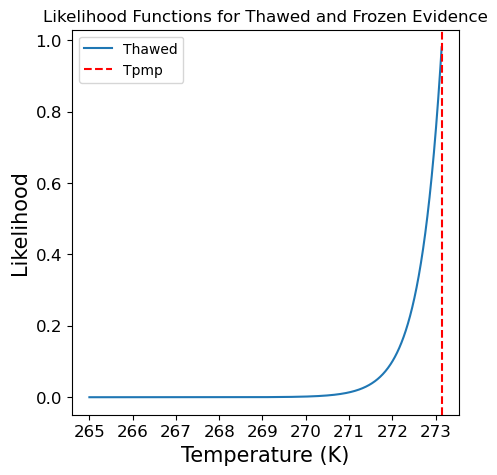

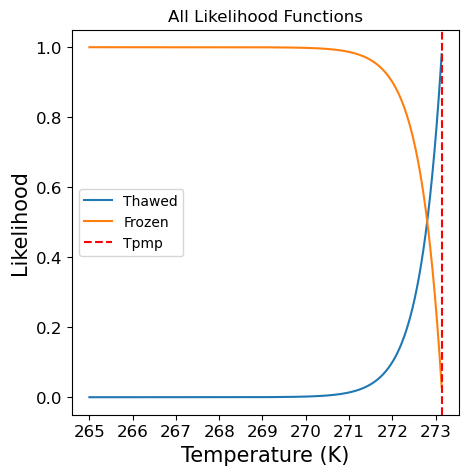

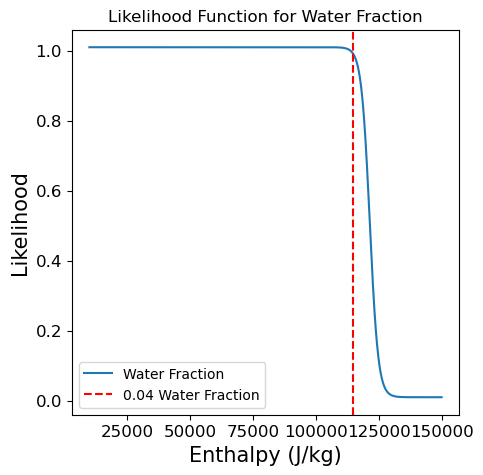

In [16]:
Tpmp = 273.15
Cp = 2030
dw = 1
df = 1
beta = 0.5
beta_w = 0.005
wf_threshold = 0.04
Tb_start = 265
Tref = 223.15
L = 334.4e3 # latent heat of fusion for water in J/kg

Eb_threshold = Cp * (Tpmp - Tref) + L * wf_threshold

Tb = torch.arange(Tb_start, 273.15, 0.01)
Eb = torch.arange(1e4, 1.5e5, 100)
beta_v = beta * torch.ones_like(Tb)
dw_v = dw * torch.ones_like(Tb)
df_v = df * torch.ones_like(Tb)
Tpmp_v = Tpmp * torch.ones_like(Tb)

# iterate 
likelihoods_thawed = []
likelihoods_frozen = []
likelihoods_wf = []
for i in range(len(Tb)):
    likelihoods_thawed.append(torch.exp(loglikelihood_thawed(beta_v[i], Tb[i], Tpmp_v[i], dw_v[i])))
    likelihoods_frozen.append(torch.exp(loglikelihood_frozen(beta_v[i], Tb[i], Tpmp_v[i], df_v[i])))
likelihoods_thawed = torch.stack(likelihoods_thawed)
likelihoods_frozen = torch.stack(likelihoods_frozen)
for i in range(len(Eb)):
    likelihoods_wf.append(torch.exp(loglikelihood_wf(beta_w, Eb[i], Tpmp)))
likelihoods_wf = torch.stack(likelihoods_wf)

# plot thawed only
plt.figure(figsize=(5, 5))
plt.plot(Tb.numpy(), likelihoods_thawed.numpy(), label='Thawed')
plt.xlabel('Temperature (K)',fontsize=15)
plt.ylabel('Likelihood',fontsize=15)
plt.title('Likelihood Functions for Thawed and Frozen Evidence',fontsize=12)
# add a vertical line at Tpmp
plt.axvline(x=Tpmp, color='red', linestyle='--', label='Tpmp')
# make x tick sparse
plt.xticks(np.arange(Tb_start, 274, 1))
# make tick size larger
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend()
plt.savefig('../figs/thawed_likelihood_functions.png')
plt.show()

# plot both lines in one plot
plt.figure(figsize=(5, 5))
plt.plot(Tb.numpy(), likelihoods_thawed.numpy(), label='Thawed')
plt.plot(Tb.numpy(), likelihoods_frozen.numpy(), label='Frozen')
plt.xlabel('Temperature (K)',fontsize=15)
plt.ylabel('Likelihood',fontsize=15)
plt.title('All Likelihood Functions',fontsize=12)
# add a vertical line at Tpmp
plt.axvline(x=Tpmp, color='red', linestyle='--', label='Tpmp')
# make x tick sparse
plt.xticks(np.arange(Tb_start, 274, 1))
# make tick size larger
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend()
plt.savefig('../figs/likelihood_functions.png')
plt.show()

# plot likelihood for water fraction
plt.figure(figsize=(5, 5))
plt.plot(Eb.numpy(), likelihoods_wf.numpy(), label='Water Fraction')
plt.xlabel('Enthalpy (J/kg)',fontsize=15)
plt.ylabel('Likelihood',fontsize=15)
plt.title('Likelihood Function for Water Fraction',fontsize=12)
# add a vertical line at the enthalpy corresponding to 0.04 water fraction
plt.axvline(x=Eb_threshold, color='red', linestyle='--', label=f'{wf_threshold} Water Fraction')
# make tick size larger
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend()
plt.show()

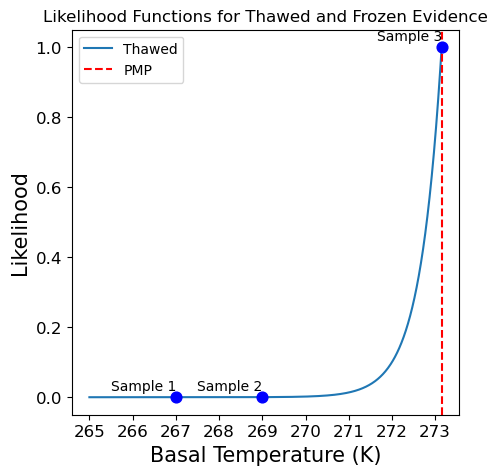

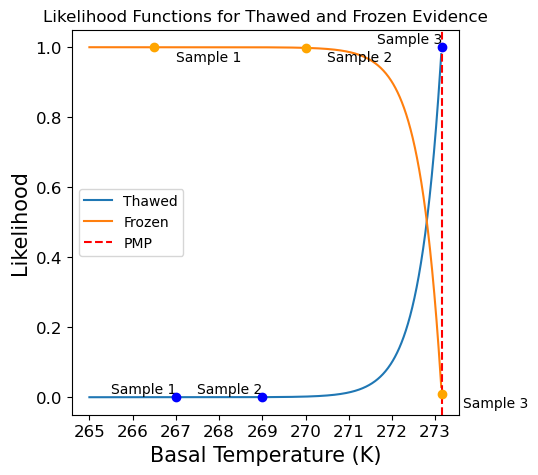

In [29]:
frozen_samples = torch.tensor([266.5, 270, 273.15])
thawed_samples = torch.tensor([267, 269, 273.15])

likelihoods_thawed_samples = []
likelihoods_frozen_samples = []
for i in range(len(frozen_samples)):
    likelihoods_thawed_samples.append(torch.exp(loglikelihood_thawed(beta_v[i], thawed_samples[i], Tpmp_v[i], dw_v[i])))
    likelihoods_frozen_samples.append(torch.exp(loglikelihood_frozen(beta_v[i], frozen_samples[i], Tpmp_v[i], df_v[i])))
likelihoods_thawed_samples = torch.stack(likelihoods_thawed_samples)
likelihoods_frozen_samples = torch.stack(likelihoods_frozen_samples)

# plot thawed only
plt.figure(figsize=(5, 5))
plt.plot(Tb.numpy(), likelihoods_thawed.numpy(), label='Thawed')
plt.scatter(thawed_samples, likelihoods_thawed_samples.numpy(), color='blue', zorder=5,s=60)
# add 'sample 1','sample 2','sample 3' next to the points
for i in range(len(thawed_samples)):
    plt.text(thawed_samples[i]-1.5, likelihoods_thawed_samples[i]+0.02, f'Sample {i+1}', fontsize=10)
plt.xlabel('Basal Temperature (K)',fontsize=15)
plt.ylabel('Likelihood',fontsize=15)
plt.title('Likelihood Functions for Thawed and Frozen Evidence',fontsize=12)
# add a vertical line at Tpmp
plt.axvline(x=Tpmp, color='red', linestyle='--', label='PMP')
# make x tick sparse
plt.xticks(np.arange(Tb_start, 274, 1))
# make tick size larger
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend()
plt.savefig('../figs/thawed_likelihood_functions_with_samples.png')
plt.show()

# plot both lines in one plot
plt.figure(figsize=(5, 5))
plt.plot(Tb.numpy(), likelihoods_thawed.numpy(), label='Thawed')
plt.plot(Tb.numpy(), likelihoods_frozen.numpy(), label='Frozen')
plt.scatter(thawed_samples, likelihoods_thawed_samples.numpy(), color='blue', zorder=5)
plt.scatter(frozen_samples, likelihoods_frozen_samples.numpy(), color='orange', zorder=5)
for i in range(len(thawed_samples)):
    plt.text(thawed_samples[i]-1.5, likelihoods_thawed_samples[i]+0.01, f'Sample {i+1}', fontsize=10)
    plt.text(frozen_samples[i]+0.5, likelihoods_frozen_samples[i]-0.04, f'Sample {i+1}', fontsize=10)
plt.xlabel('Basal Temperature (K)',fontsize=15)
plt.ylabel('Likelihood',fontsize=15)
plt.title('Likelihood Functions for Thawed and Frozen Evidence',fontsize=12)
# add a vertical line at Tpmp
plt.axvline(x=Tpmp, color='red', linestyle='--', label='PMP')
# make x tick sparse
plt.xticks(np.arange(Tb_start, 274, 1))
# make tick size larger
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend()
plt.savefig('../figs/likelihood_functions_with_samples.png')
plt.show()